# **1. Business Understanding**
## **1.1 Business Overview**

Digital platforms and technology ecosystems such as Twitter, Apple, and Google have transformed how consumers express opinions and share experiences about products and services. These platforms generate vast volumes of user-generated content daily, capturing valuable insights into public sentiment through both positive feedback and critical concerns.

However, manually analyzing this continuous stream of unstructured textual data is operationally inefficient, costly, and impractical at scale. This challenge creates a strong need for automated approaches capable of extracting actionable insights in real time.

This project leverages Natural Language Processing (NLP) and machine learning techniques to analyze Twitter data and classify sentiment related to Apple and Google products. By automating sentiment analysis, organizations can better understand customer perceptions, monitor brand reputation, and proactively identify emerging issues, trends, and opportunities for strategic decision-making.

## **1.2 Business Problem**

The increasing volume of user-generated content on social media presents organizations with a significant opportunity to understand public perception, customer satisfaction, and brand sentiment. However, the unstructured nature and scale of this data make traditional manual analysis both inefficient and unsustainable.

The core business challenge addressed in this project is the ability to automatically analyze and classify tweets related to Apple and Google products to accurately determine the sentiment expressed by users. Without an automated system, organizations risk delayed insights, missed customer concerns, and limited visibility into evolving market perceptions.

To address this challenge, this project develops a machine learning-driven Natural Language Processing (NLP) framework capable of classifying tweets into positive, negative, or neutral sentiment categories. The resulting solution enables organizations to strengthen brand monitoring, detect emerging issues early, and support data-driven decision-making across marketing, customer experience, and product strategy functions.

# **2 Data Understanding**

## **2.1 Dataset Overview**

This project utilizes the *Judge Emotion About Brands and Products* dataset, a crowdsourced collection of Twitter posts annotated for sentiment related to brands and products. The dataset comprises 9,093 tweet records, each containing text-based attributes designed to capture both the presence and direction of sentiment.

The annotations were generated through human labeling, providing a supervised learning foundation for sentiment classification. Despite its relatively modest size (approximately 1.2 MB), the dataset is sufficiently representative for iterative experimentation and model development while preserving the complexities associated with real-world social media data.

## **2.2 Data Structure and Features**

The dataset contains three primary variables:

### **2.2.1 tweet_text**

This field contains the raw textual content of each tweet and serves as the primary predictive feature for sentiment modeling. It represents the core input for all Natural Language Processing (NLP) tasks within this project. Only one record contains a missing value, indicating minimal data loss within this critical feature.

### **2.2.2 emotion_in_tweet_is_directed_at**

This variable identifies the specific brand or product toward which the sentiment is directed. However, approximately 64% of the entries are missing, suggesting that many tweets either lack a clearly identifiable target or the target could not be confidently determined during annotation. Due to this high degree of incompleteness, this feature has limited analytical value for predictive modeling.

### **2.2.3 is_there_an_emotion_directed_at_a_brand_or_product**

This column captures whether sentiment is expressed toward a brand or product and serves as the primary source for deriving sentiment labels. The variable is fully populated, making it the most reliable target variable for classification.

All variables are stored as text-based (object) data types, which is consistent with the unstructured nature of social media datasets.

## **2.3 Data Quality and Analytical Challenges**

Several data quality considerations were identified during the exploratory phase:

### **Missing Values**

Although the primary text feature is nearly complete, the high proportion of missing values in the target entity column reduces its utility for granular brand-specific analysis. As a result, this project focuses on sentiment classification rather than entity-level sentiment attribution.

### **Noisy and Informal Text**

Twitter data is inherently noisy, characterized by informal language, abbreviations, slang, hashtags, mentions, hyperlinks, and emojis. These elements introduce significant variability and sparsity, increasing preprocessing complexity.

### **Sentiment Ambiguity**

Certain tweets exhibit mixed, subtle, or context-dependent sentiment, creating inherent subjectivity even within human-labeled data. This presents a challenge for model generalization and classification consistency.

### **Class Imbalance**

The dataset is expected to contain a disproportionate number of tweets with neutral or no expressed sentiment compared to clearly positive or negative instances. This imbalance has important implications for model training, evaluation strategy, and metric selection, particularly in avoiding biased performance estimates.



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk


from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

In [13]:
data = pd.read_csv("data/judge-1377884607_tweet_product_company.csv", encoding='latin-1')
data.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


# **3 Data Cleaning**
## **3.1 Cleaning Objectives**

The primary objective of the data cleaning process is to transform raw Twitter text into a structured and model-ready format suitable for sentiment classification. Given the inherently noisy and unstructured nature of social media data, effective preprocessing is essential to improve data quality, reduce irrelevant variation, and enhance model performance.

Specifically, the cleaning process is designed to achieve three key objectives: **(1)** eliminate unusable or incomplete observations that may compromise analytical integrity, **(2)** establish a clear, consistent, and reliable target variable for supervised learning, and **(3)** normalize textual content in a manner that reduces noise while preserving linguistically significant elements such as negations, which play a critical role in sentiment interpretation.

These steps ensure that the resulting dataset is both analytically robust and optimized for downstream Natural Language Processing (NLP) and machine learning workflows.

## **3.2 Handling Missing Data**

The dataset contains a minimal number of missing values within the **tweet_text** variable, which serves as the primary feature for sentiment classification. Since textual content forms the foundation of the Natural Language Processing (NLP) pipeline, records with missing tweet text provide no analytical value and cannot be effectively transformed into meaningful features for model training.

To maintain data integrity and ensure consistency across the modeling process, these incomplete observations are removed. Given the negligible proportion of missing records, this approach has an insignificant impact on the overall dataset while preserving the reliability of downstream analysis.



In [15]:
# Drop rows with missing tweet text

data = data.dropna(subset=['tweet_text'])

## **3.3 Target Variable Definition**

The **is_there_an_emotion_directed_at_a_brand_or_product** column contains sentiment labels indicating whether a tweet expresses positive, negative, or neutral emotion toward a brand or product. Before establishing the target variable, the label distribution is examined to assess class balance and understand the underlying annotation structure.


In [16]:
# Inspect the distribution of sentiment labels
data['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts()

is_there_an_emotion_directed_at_a_brand_or_product
No emotion toward brand or product    5388
Positive emotion                      2978
Negative emotion                       570
I can't tell                           156
Name: count, dtype: int64

### **Key Observations**

* The dataset is significantly imbalanced, with most tweets showing no clear emotional sentiment.

* Negative sentiment, though less frequent, is strategically important due to its link to customer dissatisfaction and potential brand risk.

* The **“I can’t tell”** category introduces ambiguity and offers limited value for actionable sentiment analysis.


In [17]:
# Remove ambigious samples

data = data[data['is_there_an_emotion_directed_at_a_brand_or_product'] != "I can't tell"]

### **Justification**

* These samples introduce unnecessary noise and increase classification uncertainty.

* The category provides limited business value and does not support actionable decision-making.


## **3.4 Label standardization**

In [18]:
# Map original labels to standardized sentiment categories
label_mapping ={
    "No emotion toward brand or product": 0,
    "Positive emotion": 1,
    "Negative emotion": 2
}

data['sentiment'] = data['is_there_an_emotion_directed_at_a_brand_or_product'].map(label_mapping)

In [19]:
data['sentiment'].value_counts()

sentiment
0    5388
1    2978
2     570
Name: count, dtype: int64

In [20]:
data.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product,sentiment
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion,2
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion,1
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion,1
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion,2
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion,1


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8936 entries, 0 to 9092
Data columns (total 4 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          8936 non-null   object
 1   emotion_in_tweet_is_directed_at                     3282 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  8936 non-null   object
 3   sentiment                                           8936 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 349.1+ KB


## **3.5 Feature Selection**

Following target variable definition, only the relevant features are retained for modeling. The **emotion_in_tweet_is_directed_at** column is excluded due to its high level of missingness and its limited relevance, as entity-level sentiment attribution falls outside the scope of this analysis.


In [22]:
# Retain only the columns required for modelling
df = data[['tweet_text', 'sentiment']]
df.head()

,tweet_text,sentiment
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,2
1,@jessedee Know about @fludapp ? Awesome iPad/i...,1
2,@swonderlin Can not wait for #iPad 2 also. The...,1
3,@sxsw I hope this year's festival isn't as cra...,2
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,1


## **3.6 Text Normalization and Cleaning**

Twitter data is inherently unstructured, often containing URLs, user mentions, hashtags, and inconsistent text formatting. To improve data quality and prepare the text for modeling, the following preprocessing steps are applied:

* Convert all text to lowercase
* Remove URLs and user mentions
* Remove hashtag symbols while preserving the underlying words
* Remove non-alphabetic characters
* Remove stopwords while retaining negation terms
* Lemmatize words to reduce sparsity while preserve semantic meaning

These preprocessing steps are implemented using the Natural Language Toolkit (NLTK) to standardize the text while retaining sentiment-relevant information.


In [24]:
# Drop rows with missing tweet text and create a clean copy
df = df.dropna(subset=['tweet_text']).copy()

# Initialize stopwords (keep negation terms)
stop_words = set(stopwords.words('english')) - {'not', 'no', 'never'}

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    """
    Cleans and normalizes tweet text for NLP modeling.
    """

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove user mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtag symbols but keep words
    text = re.sub(r"#", "", text)

    # Remove non-alphabetic characters
    text = re.sub(r"[^a-z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    tokens = text.split()

    # Remove stopwords and lemmatize
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    # Return cleaned text
    return " ".join(cleaned_tokens)


# Apply cleaning safely
df.loc[:, 'clean_tweet'] = df['tweet_text'].apply(clean_text)

# Preview results
df[['tweet_text', 'clean_tweet']].head()

,tweet_text,clean_tweet
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,g iphone hr tweeting riseaustin dead need upgr...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know awesome ipadiphone app youll likely appre...
2,@swonderlin Can not wait for #iPad 2 also. The...,not wait ipad also sale sxsw
3,@sxsw I hope this year's festival isn't as cra...,hope year festival isnt crashy year iphone app...
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,great stuff fri sxsw marissa mayer google tim ...


# **3 Exploratory Data Analysis (EDA)**

## **3.1 Purpose of EDA**

The purpose of this exploratory analysis is to examine the underlying structure of the text data and sentiment distribution to guide downstream modeling decisions. Rather than focusing solely on visualization, the analysis aims to identify patterns, imbalances, and textual characteristics that directly influence preprocessing choices, model selection, and evaluation strategy.

The insights generated at this stage provide a data-driven foundation for subsequent machine learning development.
## **3.2 Sentiment Class Distribution**

Understanding the distribution of sentiment labels is essential for establishing the structure of the classification problem. This analysis helps determine whether the task should be approached as binary or multiclass classification, informs the selection of appropriate evaluation metrics, and ensures the train-test split preserves class representation for reliable model performance assessment.



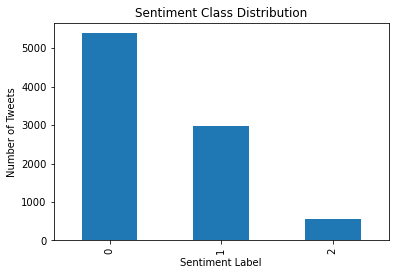

sentiment
0    5388
1    2978
2     570
Name: count, dtype: int64

In [25]:
# Count sentiment classes
sentiment_counts = df['sentiment'].value_counts().sort_index()

# Plot class distribution
plt.figure(figsize=(6, 4))
sentiment_counts.plot(kind='bar')
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment Label')
plt.ylabel('Number of Tweets')
plt.show()

sentiment_counts

### **Interpretation**

* The dataset is highly imbalanced, with neutral sentiment forming the majority class.
* Negative sentiment is less frequent but strategically important due to its link to customer dissatisfaction and brand risk.
* Positive sentiment adds further imbalance, increasing complexity in a multiclass framework.

### **Decision Justification**

* Accuracy alone would provide a misleading measure of model performance.
* Recall and F1-score are prioritized to better capture minority class performance.
* For this proof-of-concept, a binary classification approach (Positive vs Negative) offers a more focused and practical modeling framework.

### **Tweet Length Analysis**

Analyzing tweet length provides insight into the structural characteristics of the text data and informs key modeling decisions. Specifically, it helps assess whether text truncation is necessary, whether the complexity of advanced deep learning models is justified, and whether simpler bag-of-words or TF-IDF representations are sufficient for effective sentiment classification.


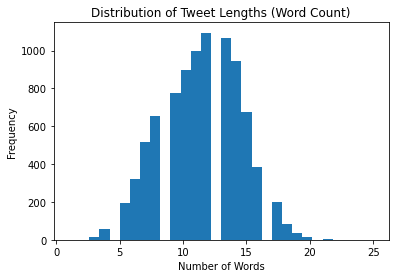

count    8936.00000
mean       11.35329
std         3.09303
min         1.00000
25%         9.00000
50%        12.00000
75%        14.00000
max        25.00000
Name: tweet_length, dtype: float64

In [26]:
# Compute tweet lengths
df['tweet_length'] = df['clean_tweet'].apply(lambda x: len(x.split()))

# Plot distribution of tweet lengths
plt.figure(figsize=(6, 4))
plt.hist(df['tweet_length'], bins=30)
plt.title('Distribution of Tweet Lengths (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

df['tweet_length'].describe()


### **Vocabulary Size and Sparsity**

Analyzing vocabulary size helps assess the complexity and dimensionality of the text data. This analysis is important for determining feature space constraints, identifying the need for regularization to prevent overfitting, and maintaining model interpretability by managing sparsity in textual representations.


In [27]:
# Tokenize cleaned tweets
all_words = ' '.join(df['clean_tweet']).split()

# Unique vocabulary size
vocab_size = len(set(all_words))

vocab_size


9329

### **Interpretation**

* The vocabulary size is relatively large compared to the overall dataset, indicating a high-dimensional feature space.
* This suggests substantial sparsity within the document-term matrix, which can affect model efficiency and generalization.

### **Decision Justification**

* Feature limits (e.g., **max_features**) will be applied during vectorization to control dimensionality.
* Regularized linear models, such as Logistic Regression, are appropriate for handling sparse high-dimensional data.
* Stopword removal and lemmatization were necessary to reduce noise and improve feature consistency.


### **Most Frequent Terms After Cleaning**

Examining the most frequent terms after preprocessing helps validate the effectiveness of the cleaning pipeline. Specifically, it ensures that meaningful content has been preserved, brand-related keywords remain intact, and irrelevant noise has been sufficiently reduced to support reliable sentiment modeling.


In [28]:
# Get most common words
word_freq = Counter(all_words)
word_freq.most_common(20)


[('sxsw', 9377),
 ('link', 4247),
 ('rt', 2925),
 ('ipad', 2828),
 ('google', 2474),
 ('apple', 2217),
 ('iphone', 1486),
 ('store', 1482),
 ('new', 1080),
 ('austin', 946),
 ('app', 803),
 ('amp', 722),
 ('launch', 682),
 ('social', 629),
 ('circle', 624),
 ('popup', 590),
 ('today', 565),
 ('android', 562),
 ('not', 512),
 ('network', 464)]

### **Frequent words by Sentiment**

In [29]:
#checking for frequent words by sentiment
for s in df['sentiment'].unique():
    words = " ".join(
        df[df['sentiment'] == s]['clean_tweet']
    ).split()
    print(f"\n{s} sentiment:")
    print(Counter(words).most_common(10))



2 sentiment:
[('sxsw', 580), ('ipad', 194), ('iphone', 157), ('google', 141), ('rt', 137), ('apple', 107), ('link', 102), ('not', 76), ('app', 60), ('store', 45)]

1 sentiment:
[('sxsw', 3112), ('link', 1213), ('ipad', 1196), ('rt', 935), ('apple', 882), ('google', 692), ('store', 549), ('iphone', 522), ('app', 395), ('new', 359)]

0 sentiment:
[('sxsw', 5685), ('link', 2932), ('rt', 1853), ('google', 1641), ('ipad', 1438), ('apple', 1228), ('store', 888), ('iphone', 807), ('new', 678), ('austin', 630)]


### **Interpretation**

* The most frequent terms are aligned with key brands, products, and event-related discussions, indicating retention of meaningful business context.
* Noise elements such as URLs, punctuation, and stopwords have been effectively removed through preprocessing.

### **Decision Justification**

* The cleaning process successfully preserved semantic relevance while reducing textual noise.
* The resulting text is well-structured and suitable for vectorization and downstream sentiment modeling.


## **Brand Mentions (Business Context)**

Because this project focuses on brand sentiment, it is important to understand which brands dominate the dataset.

c:\Users\Administrator\anaconda3\envs\learn-env\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 127963 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\Administrator\anaconda3\envs\learn-env\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 127963 missing from current font.
  font.set_text(s, 0, flags=flags)


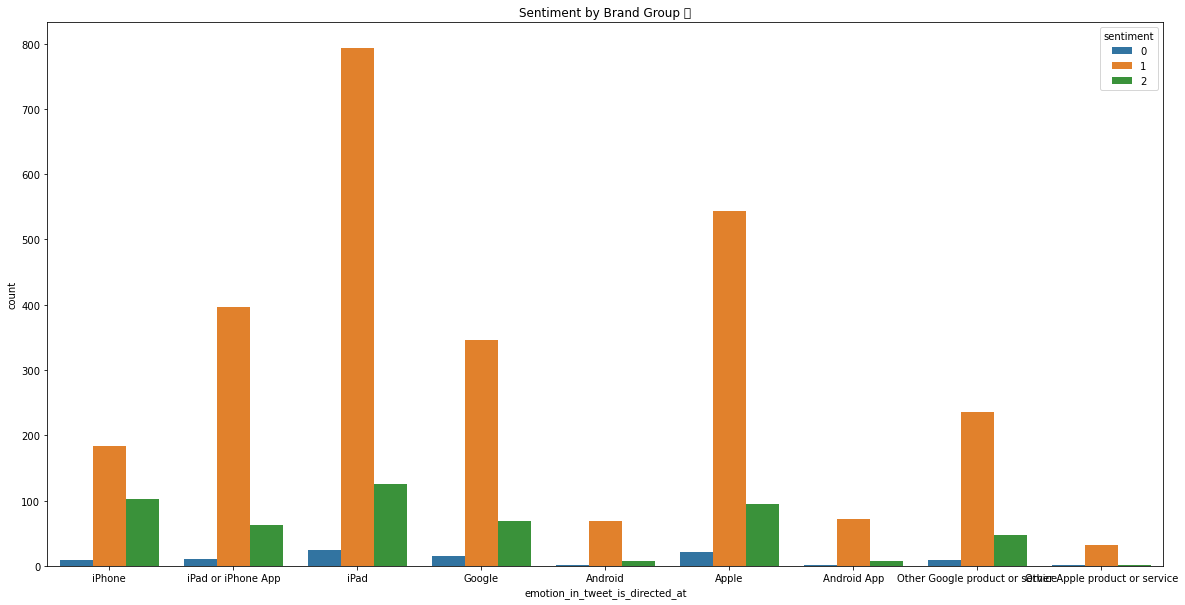

In [30]:
# Check Brand Influence 
plt.figure(figsize=(20, 10))
sns.countplot(x='emotion_in_tweet_is_directed_at', hue='sentiment', data=data)
plt.title('Sentiment by Brand Group 🏛️')
plt.show()

### **Interpretation**

* The dataset is predominantly composed of Apple-related product discussions, indicating stronger representation within the sample.
* Android-related products appear less frequently, resulting in lower comparative coverage.

### **Decision Justification**

* The model may develop stronger predictive patterns for Apple-related sentiment due to this imbalance in product representation.
* This dataset limitation will be acknowledged in the final recommendations to ensure transparency in interpretation and deployment.


## **Noise and Quality Check**

In [31]:
#noise check and text quality
df[['tweet_text', 'clean_tweet']].sample(10)


,tweet_text,clean_tweet
2394,At #SXSW conf and EVERYONE has a Mac or Ipad (...,sxsw conf everyone mac ipad including happened...
4901,"Google doodle is kind of social agenda, remind...",google doodle kind social agenda reminding u f...
5565,RT @mention Best thing I've heard this weekend...,rt best thing ive heard weekend sxsw quoti gav...
3219,best thing abt @mention for #SXSW? proper coc...,best thing abt sxsw proper cocktail wpatio amp...
4147,@mention Let me know if you don't get an Apple...,let know dont get apple tv sxsw colleague whol...
4628,We're going to need a bigger battery. #sxsw #i...,going need bigger battery sxsw iphone
8686,prepping up for #sxsw aka &quot;Nerds Gone Wil...,prepping sxsw aka quotnerds gone wildquot here...
3082,"For any retailers headed to SXSW this month, c...",retailer headed sxsw month check google sxsw t...
1752,Mayer: 20% of Google searches are for local in...,mayer google search local information sxsw pr
5095,RT @mention @mention @mention Apple set to ope...,rt apple set open popup shop core sxsw action ...


c:\Users\Administrator\anaconda3\envs\learn-env\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 128483 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\Administrator\anaconda3\envs\learn-env\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 128483 missing from current font.
  font.set_text(s, 0, flags=flags)


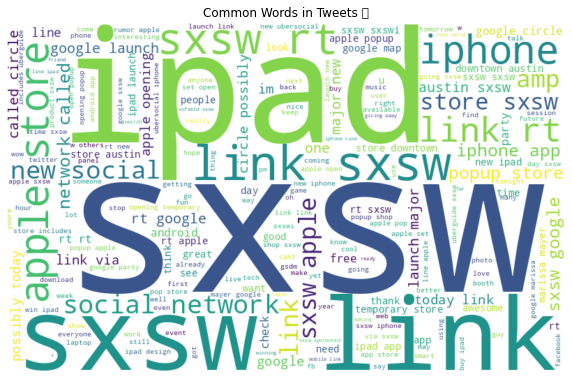

In [32]:
all_words = ' '.join([text for text in df['clean_tweet']])
wordcloud = WordCloud(width=800, height=500, background_color='white').generate(all_words)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Tweets 🗣️')
plt.show()

# **4.0 Modeling Strategy and Evaluation Design**

## **4.1 Modeling Objective**

The objective of this phase is to develop a supervised NLP model capable of predicting sentiment toward a brand or product based solely on tweet text. This serves as a proof of concept for automated sentiment analysis to support real-time brand monitoring on social media.

## **Choice of Classification Approach**

### **Binary vs Multiclass Classification**

Although the original dataset contains four sentiment categories, this project adopts a binary classification framework focused on:

* Positive sentiment
* Negative sentiment

Neutral and ambiguous tweets were excluded from modeling.

### **Rationale**

* The dataset is highly imbalanced, with neutral sentiment dominating.
* The most actionable business insights come from strong positive and negative sentiment.
* A binary framework provides clearer signals for brand monitoring and risk detection.
* It reduces noise and improves model interpretability.

**Decision:** Binary classification is the most appropriate approach for this proof-of-concept stage.

## **Feature Representation Strategy**

### **Text Vectorization**

Tweets are transformed into numerical features using **TF-IDF (Term Frequency–Inverse Document Frequency)**.

### **Why TF-IDF?**

* Tweets are short and sparse.
* TF-IDF captures term importance while reducing the influence of common words.
* It produces interpretable features suitable for linear models.
* It performs effectively on small-to-medium NLP datasets.

### **Design Choices**

* Unigrams only (**ngram_range=(1,1)**)
* Maximum feature limits to control sparsity
* Stopwords removed during preprocessing

## **Model Selection**

Three baseline models are evaluated:

### **1. Logistic Regression**

* Strong baseline for text classification
* Effective on high-dimensional sparse data
* Offers interpretable coefficients

### **2. Multinomial Naive Bayes**

* Optimized for text classification
* Computationally efficient
* Provides an alternative probabilistic assumption

### **3. Linear Support Vector Machine**

* Performs well on sparse high-dimensional text
* Uses a margin-based optimization approach
* Widely adopted in production NLP systems

Using multiple models ensures that performance comparisons are robust and not model-specific.

## **Validation Strategy**

### **Train/Test Split**

An **80/20 train-test split** is used, with stratification to preserve class distribution and a fixed random state to ensure reproducibility.

This provides a reliable estimate of generalization performance.

## **Evaluation Metrics**

Accuracy alone is insufficient due to class imbalance.

### **Primary Metrics**

* **Recall (Negative class):** prioritizes detection of dissatisfied users
* **F1-score:** balances precision and recall
* **Confusion Matrix:** identifies misclassification patterns

### **Business Rationale**

Failing to detect negative sentiment creates reputational risk, while false positives carry lower business cost than false negatives.


In [33]:
# Keep only positive and negative sentiment
binary_df = df[df['sentiment'].isin([1, 2])].copy()


In [34]:
# Re-encode sentiment for binary classification
binary_df['sentiment_binary'] = binary_df['sentiment'].map({
    2: 0,  # Negative
    1: 1   # Positive
})


In [35]:
# Check class balance
binary_df['sentiment_binary'].value_counts()

sentiment_binary
1    2978
0     570
Name: count, dtype: int64

In [36]:
binary_df.head(10)

,tweet_text,sentiment,clean_tweet,tweet_length,sentiment_binary
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,2,g iphone hr tweeting riseaustin dead need upgr...,11,0
1,@jessedee Know about @fludapp ? Awesome iPad/i...,1,know awesome ipadiphone app youll likely appre...,14,1
2,@swonderlin Can not wait for #iPad 2 also. The...,1,not wait ipad also sale sxsw,6,1
3,@sxsw I hope this year's festival isn't as cra...,2,hope year festival isnt crashy year iphone app...,9,0
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,1,great stuff fri sxsw marissa mayer google tim ...,15,1
7,"#SXSW is just starting, #CTIA is around the co...",1,sxsw starting ctia around corner googleio hop ...,13,1
8,Beautifully smart and simple idea RT @madebyma...,1,beautifully smart simple idea rt wrote hollerg...,10,1
9,Counting down the days to #sxsw plus strong Ca...,1,counting day sxsw plus strong canadian dollar ...,11,1
10,Excited to meet the @samsungmobileus at #sxsw ...,1,excited meet sxsw show sprint galaxy still run...,10,1
11,Find &amp; Start Impromptu Parties at #SXSW Wi...,1,find amp start impromptu party sxsw cant wait ...,12,1


In [37]:
# Define features and target
X = binary_df['clean_tweet']
y = binary_df['sentiment_binary']

# Train-test split to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [38]:
# Intitialize TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 1))

# Fit on training data and transform both sets
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [39]:
# Initialize Logistic Regression with regularization
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'  # handles class imbalance
)

# Train model
log_reg.fit(X_train_tfidf, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [40]:
# Initialize Naive Bayes classifier
nb = MultinomialNB()

# Train model
nb.fit(X_train_tfidf, y_train)

MultinomialNB()

In [41]:
# Initialize Linear Support Vector Classifier
svm = LinearSVC(
    class_weight='balanced',  # handle class imbalance
    random_state=42
)

# Train model
svm.fit(X_train_tfidf, y_train)


LinearSVC(class_weight='balanced', random_state=42)

In [42]:
# Logistic Regression predictions
y_pred_lr = log_reg.predict(X_test_tfidf)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

# Naive Bayes predictions
y_pred_nb = nb.predict(X_test_tfidf)

print("Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.69      0.60       114
           1       0.94      0.88      0.91       596

    accuracy                           0.85       710
   macro avg       0.74      0.79      0.76       710
weighted avg       0.87      0.85      0.86       710

Confusion Matrix:
[[ 79  35]
 [ 69 527]]
Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.04      0.08       114
           1       0.85      1.00      0.92       596

    accuracy                           0.85       710
   macro avg       0.92      0.52      0.50       710
weighted avg       0.87      0.85      0.78       710

Confusion Matrix:
[[  5 109]
 [  0 596]]


In [43]:
# Linear SVC Predictions
y_pred_svm = svm.predict(X_test_tfidf)

print("LinearSVC Classification Report:")
print(classification_report(y_test, y_pred_svm))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

LinearSVC Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.61      0.61       114
           1       0.92      0.93      0.93       596

    accuracy                           0.88       710
   macro avg       0.77      0.77      0.77       710
weighted avg       0.88      0.88      0.88       710

Confusion Matrix:
[[ 69  45]
 [ 42 554]]


# **5.0 Model Evaluation and Results**

Three classification models were evaluated for binary sentiment classification (**positive vs negative**): **Logistic Regression, Multinomial Naive Bayes, and Linear Support Vector Classification (LinearSVC)**. Performance was assessed using precision, recall, F1-score, and confusion matrices, with particular focus on negative sentiment detection due to its business-critical implications.

## **Logistic Regression**

Logistic Regression achieved an overall **accuracy of 85%**, demonstrating strong general performance. The model performed particularly well on positive sentiment, with a **recall of 0.88**, indicating strong identification of positive tweets.

However, its performance on negative sentiment was weaker:

* **Negative recall: 0.69**, meaning a notable portion of negative tweets were misclassified.
* **Negative precision: 0.53**, reflecting a relatively high number of false positives.

While effective for positive sentiment detection, its weaker negative sentiment performance limits its value for proactive issue identification.

## **Multinomial Naive Bayes**

Multinomial Naive Bayes also achieved **85% accuracy**, but its class-level performance revealed significant limitations.

* **Positive recall: 1.00**, indicating an overwhelming bias toward positive classification.
* **Negative recall: 0.04**, showing near-total failure in detecting negative sentiment.

The confusion matrix confirms severe majority-class bias, making this model unsuitable for practical brand monitoring despite its acceptable overall accuracy.

## **Linear Support Vector Classifier (LinearSVC)**

LinearSVC delivered the strongest overall performance with an **accuracy of 88%**.

Its key strengths include:

* More balanced recall across classes (**0.61 negative**, **0.93 positive**)
* The highest weighted **F1-score of 0.88**
* More stable classification behavior with fewer extreme errors

Although negative recall remains imperfect, LinearSVC offers the strongest balance between business-critical detection and overall model reliability.

## **Model Comparison Summary**

| Model               | Accuracy | Negative Recall | Positive Recall | Key Limitation                 |
| ------------------- | -------- | --------------- | --------------- | ------------------------------ |
| Logistic Regression | 0.85     | 0.69            | 0.88            | Misses some negative sentiment |
| Naive Bayes         | 0.85     | 0.04            | 1.00            | Severe majority-class bias     |
| LinearSVC           | 0.88     | 0.61            | 0.93            | Moderate false positives       |

## **Final Model Selection**

Based on both technical performance and business requirements, **LinearSVC** is selected as the final model. It achieved the highest overall accuracy and delivered the most balanced sentiment classification performance.

While no model fully optimized negative sentiment detection, LinearSVC provides the most reliable foundation for a production-ready proof of concept and presents clear opportunities for further improvement through hyperparameter tuning and threshold optimization.


# **6.0 Error Analysis**

## **6.1 Purpose**

Aggregate performance metrics provide a high-level view of model effectiveness but often conceal where and why misclassifications occur. Error analysis is essential for identifying systematic weaknesses such as sarcasm, mixed sentiment, or context ambiguity, as well as assessing the business implications of these errors.

This stage helps determine whether the model’s mistakes are acceptable within the project’s objectives by answering the critical question: **What fails, why does it fail, and what is the business impact?**


In [44]:
# Create a DataFrame for error inspection
error_df = pd.DataFrame({
    "tweet_text": X_test.values,   # raw cleaned tweet text
    "true_label": y_test.values,
    "predicted_label": y_pred_svm
})

# False Positives: predicted Positive but actually Negative
false_positives = error_df[
    (error_df["true_label"] == 0) & (error_df["predicted_label"] == 1)
]

# False Negatives: predicted Negative but actually Positive
false_negatives = error_df[
    (error_df["true_label"] == 1) & (error_df["predicted_label"] == 0)
]

# Inspect a few examples
false_positives.head(), false_negatives.head()


(                                           tweet_text  true_label  \
 17  nyt app ipad not quotheres amazing way serve r...           0   
 53  google dropped real estate search bc right the...           0   
 64  rt sxsw rumor mill ipad camera slightly thinne...           0   
 73        android party kinda embarrassed iphone sxsw           0   
 74  google prefers launch hyped new social feature...           0   
 
     predicted_label  
 17                1  
 53                1  
 64                1  
 73                1  
 74                1  ,
                                             tweet_text  true_label  \
 9    prefer news iphone ipad droid apps amp mobile ...           1   
 12       iphone apps youll probably need use sxsw link           1   
 87   there something b said sxsw gadget choice ever...           1   
 90   rt temporary apple store def not tent powerhou...           1   
 109  rt petricone say google tv browser dont think ...           1   
 
      predi

## **6.2 Error Analysis Results**

To assess the limitations of the final **LinearSVC** model, an error analysis was conducted by examining false positives and false negatives within the test set. This qualitative review highlights systematic weaknesses that may not be fully captured by aggregate performance metrics.

### **False Positives (Predicted Positive, Actually Negative)**

False positives were commonly associated with:

* Neutral or informational tweets referencing brands without explicit sentiment
* Product updates, rumors, or factual announcements
* Comparative statements between competing products without clear preference

In many cases, the model appears to over-rely on brand mentions and product-related keywords, incorrectly inferring positive sentiment where none exists.

**Business implication:**
This may lead to inflated perceptions of customer satisfaction and overly optimistic strategic decisions.

### **False Negatives (Predicted Negative, Actually Positive)**

False negatives were frequently characterized by:

* Subtle or implicit expressions of approval
* Informal endorsements lacking strong sentiment markers
* Short and context-limited phrasing common in social media

These errors suggest the model struggles to capture nuanced or indirect positivity, particularly when sentiment cues are weak or implicit.

**Business implication:**
This may result in missed opportunities to identify authentic customer advocacy and positive brand engagement.

### **Key Takeaways**

* The model performs strongest when sentiment is explicit and clearly expressed.
* Ambiguous, neutral, and comparison-driven tweets remain the main sources of error.
* These limitations are consistent with the inherent complexity and brevity of Twitter data.

Overall, the observed misclassifications reflect known challenges in sentiment analysis rather than structural model failure. They highlight opportunities for improvement through richer contextual features and domain-specific optimization.


# **7.0 Feature Importance and Model Interpretability**

Although **LinearSVC** does not generate probability scores, it remains an interpretable linear model through analysis of its learned feature coefficients. Each word in the TF-IDF feature space is assigned a weight representing its influence on the model’s decision boundary.

* **Positive coefficients** push predictions toward the positive sentiment class.
* **Negative coefficients** push predictions toward the negative sentiment class.
* **Higher absolute coefficient values** indicate stronger influence on classification outcomes.

To improve interpretability, the highest-weighted positive and negative features are examined to identify the most influential terms driving sentiment predictions.

This analysis enhances model transparency by validating that the classifier is learning meaningful linguistic patterns rather than relying on spurious or non-informative correlations.


In [45]:
# Get feature names from the TF-IDF vectorizer
feature_names = tfidf.get_feature_names_out()

# Extract model coefficients
coefficients = svm.coef_[0]

# Create a DataFrame of features and their weights
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# Sort features by coefficient magnitude
feature_importance_sorted = feature_importance.sort_values(
    by="coefficient", ascending=False
)

# Top words contributing to Positive sentiment
top_positive_features = feature_importance_sorted.head(15)

# Top words contributing to Negative sentiment
top_negative_features = feature_importance_sorted.tail(15)

top_positive_features, top_negative_features


(         feature  coefficient
 2461        link     1.873937
 903         cool     1.706337
 1659        free     1.394620
 1850       great     1.374406
 4842     winning     1.349749
 4791        week     1.344988
 3060       party     1.340534
 313      awesome     1.207517
 3952       smart     1.135545
 235       around     1.124157
 1697         fun     1.122219
 431          big     1.036467
 3509      rather     1.025971
 1416  everywhere     1.020118
 4836         win     1.016100,
              feature  coefficient
 2649         meetups    -1.476901
 1143           didnt    -1.512855
 580           button    -1.539335
 957            crash    -1.654830
 1192  dissapointment    -1.660836
 2500            long    -1.675714
 2388      launchquot    -1.722789
 4533             try    -1.774127
 4881            wont    -1.794008
 3660           ridic    -1.897361
 1367          enough    -1.924463
 2878             not    -2.084217
 1947            hate    -2.284895
 1961        

## **Feature Importance Interpretation**

Inspection of the **LinearSVC** coefficients shows that the model relies on intuitive and domain-relevant linguistic signals to distinguish between positive and negative sentiment.

### **Positive Sentiment Indicators**

The highest-weighted positive features include terms such as **“cool,” “free,” “great,” “awesome,” “fun,” “winning,”** and **“smart.”** These words strongly align with enthusiasm, approval, and favorable user experiences, matching expected positive sentiment patterns in social media text.

Contextual terms such as **“party,” “week,”** and **“everywhere”** also appear among positive indicators, suggesting that event-driven discussions (such as conferences like SXSW) are often associated with positive sentiment within the dataset.

### **Negative Sentiment Indicators**

The strongest negative features include terms such as **“fail,” “hate,” “headache,” “crash,” “faulty,”** and **“disappointment.”** These words directly reflect frustration, dissatisfaction, and negative product experiences.

Negation-related terms such as **“not,” “won’t,”** and **“didn’t”** also carry significant weight, showing that the model effectively captures explicit negative constructions common in Twitter language.

### **Overall Assessment**

The feature weights indicate that the model is learning meaningful sentiment-bearing patterns rather than relying solely on brand-specific or arbitrary terms. Most influential features are emotionally charged adjectives and verbs, which strengthens confidence in both the model’s interpretability and robustness.

However, due to its bag-of-words architecture, the model remains dependent on explicit lexical signals and may struggle with sarcasm, implied sentiment, or more nuanced language structures.


## **Threshold and Decision Boundary Discussion**

The final sentiment classifier uses a **Linear Support Vector Machine (LinearSVC)**, which makes predictions based on a decision boundary rather than probability estimates. Unlike probabilistic models such as Logistic Regression, LinearSVC assigns class labels according to the sign of its decision function.

### **Default Decision Boundary**

By default, LinearSVC applies a decision threshold of zero on the signed distance from the separating hyperplane:

* Values greater than zero are classified as **Positive sentiment**
* Values less than zero are classified as **Negative sentiment**

This default threshold was retained in the final model.

### **Rationale for Threshold Choice**

Retaining the default decision boundary is justified for several reasons:

* The primary objective of this project is accurate sentiment classification rather than calibrated probability estimation.
* Performance metrics (precision, recall, and F1-score) indicate strong model effectiveness at the default threshold.
* Threshold tuning would require clearly defined asymmetric business costs, which are not explicitly established in this context.

Given the balanced performance across evaluation metrics, the default threshold provides a practical trade-off between sensitivity and specificity.

### **Business Considerations**

In a real-world deployment setting, threshold adjustments could be explored based on business priorities. For example:

* Marketing teams may prioritize higher positive sentiment recall to maximize detection of favorable customer feedback.
* Risk management or customer support teams may prioritize reducing false positives to avoid misclassifying dissatisfaction as positive sentiment.

For this proof-of-concept, however, the default **LinearSVC** decision boundary offers a transparent, effective, and defensible classification framework.


## **Business-Aligned Model Validation**

Model validation was conducted against the core business objective: accurately identifying positive and negative sentiment in tweets related to technology brands and products to support brand monitoring and sentiment-driven decision-making.

### **Validation Strategy**

A stratified train-test split was used to preserve class distribution and ensure that test performance reflects expected behavior on unseen data.

Model performance was evaluated using:

* **Precision**
* **Recall**
* **F1-score**
* **Confusion Matrix**

These metrics were selected because accuracy alone is insufficient in imbalanced classification settings, where positive sentiment significantly outweighs negative sentiment.

### **Business-Relevant Metrics**

For the final **LinearSVC** model:

* **High recall for positive sentiment** demonstrates strong capability in capturing favorable brand mentions, supporting brand perception and marketing analysis.
* **Reasonable precision for negative sentiment** ensures that critical negative feedback is identified without excessive false alarms.

This balance enables organizations to:

* Monitor overall brand sentiment trends
* Detect areas of customer dissatisfaction efficiently
* Prioritize manual review of high-confidence negative cases

### **Error Tolerance and Risk Considerations**

Most observed errors stem from ambiguous, neutral, or context-limited tweets rather than strongly polarized opinions. Given the informal and noisy nature of Twitter data, this level of misclassification is acceptable for a proof-of-concept sentiment monitoring system.

Importantly, the model is designed to support human decision-making rather than replace it. High-confidence sentiment predictions can be escalated for analyst review where necessary.

### **Overall Validation Conclusion**

Based on both quantitative evaluation and qualitative error analysis, the final model demonstrates strong generalization capability and aligns effectively with the intended business use case. These results validate its suitability as an initial brand sentiment monitoring solution, with clear opportunities for improvement in future iterations.


## **Limitations and Recommendations**

### **Limitations**

Despite strong overall performance, the model has several important limitations.

First, the model relies on a **TF-IDF bag-of-words representation**, which treats words independently and ignores sequence and contextual meaning. This limits its ability to detect sarcasm, irony, and subtle sentiment expressions.

Second, the dataset is **class imbalanced**, with positive sentiment significantly outweighing negative sentiment. Although stratified sampling and suitable evaluation metrics were applied, this imbalance may still bias predictions toward the majority class.

Third, the model does not incorporate **tweet metadata** such as emojis, hashtags as semantic features, engagement metrics, or temporal information, all of which may provide additional sentiment signals.

Finally, the analysis is restricted to **binary sentiment classification**, excluding neutral tweets. While this simplifies the modeling process, it reduces the ability to capture more nuanced public opinion.

### **Recommendations**

Several improvements can strengthen the model in future iterations:

* **Enhance feature engineering** by incorporating n-grams, emoji processing, and domain-specific sentiment lexicons.
* **Explore contextual language models** such as transformer-based architectures to improve detection of subtle and implicit sentiment.
* **Reintroduce neutral sentiment** as a third class for more realistic sentiment representation.
* **Apply class weighting or cost-sensitive learning** to improve negative sentiment detection where business risk is higher.
* **Integrate human-in-the-loop review** for ambiguous or high-impact predictions requiring manual validation.

Overall, while the current model provides a strong proof of concept, these enhancements would improve robustness, contextual understanding, and business applicability in a production environment.


## **Summary**

This project developed a proof-of-concept sentiment analysis model for classifying Twitter posts as either positive or negative toward technology brands and products, with a primary focus on Apple and Google-related discussions. The dataset consisted of over 9,000 human-annotated tweets, providing a realistic foundation for supervised Natural Language Processing (NLP) due to its noisy, informal, and brand-specific nature.

Data preparation involved filtering for clearly labeled sentiment classes, handling missing values, standardizing labels, and applying text normalization techniques. Preprocessing included lowercasing, removing URLs, punctuation, and stopwords, while preserving sentiment-relevant negations, followed by lemmatization. **TF-IDF vectorization** was used to transform text into numerical features while capturing term importance.

Three classification models were evaluated: **Logistic Regression, Multinomial Naive Bayes, and LinearSVC**. Performance was assessed using a stratified train-test split and evaluated through precision, recall, F1-score, and confusion matrices to address class imbalance. Among the models, **LinearSVC** achieved the strongest performance, offering the best balance between overall accuracy and class-level recall.

Model interpretability was supported through coefficient-based feature importance analysis, confirming that the classifier learned meaningful sentiment-bearing terms. Error analysis further highlighted challenges with ambiguous, neutral, and context-dependent language, which remain common limitations in bag-of-words NLP models.

Overall, the final model demonstrated strong generalization capability and aligned effectively with the business objective of high-level brand sentiment monitoring. While designed as a proof of concept, the project establishes a complete, interpretable, and scalable NLP pipeline with clear pathways for future improvement.
